# One-Class SVM — Hyperparameter Comparison

This notebook follows the same workflow as `one_class_svm.ipynb` but runs the model across **6 hyperparameter configurations** to compare their performance.

**Configurations tested:**

| # | nu | gamma | Rationale |
|---|---|---|---|
| 1 | 0.01 | scale | Very tight boundary — default gamma |
| 2 | 0.05 | scale | Baseline — default settings |
| 3 | 0.10 | scale | Relaxed boundary — default gamma |
| 4 | 0.20 | scale | Loose boundary — default gamma |
| 5 | 0.05 | auto | Baseline nu — broader kernel bandwidth |
| 6 | 0.05 | 0.001 | Baseline nu — very smooth, wide boundary |

**What we are varying:**
- **nu** — controls how tightly the boundary wraps around the normal data. Configs 1–4 isolate this effect with `gamma='scale'` fixed. Smaller nu = tighter fit, fewer allowed training errors.
- **gamma** — controls the shape of the RBF kernel. `'scale'` uses `1 / (n_features × std)`, `'auto'` uses `1 / n_features`, and `0.001` is a manually set small value producing a very smooth, wide boundary. Configs 2, 5, 6 isolate this effect with `nu=0.05` fixed.

**kernel is fixed at `'rbf'`** and **threshold is fixed at the top 5%** of normal training scores across all configurations.

## 1. Hyperparameter Grid

All configurations are defined here. Add or remove entries to experiment with other values.

In [1]:
# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'nu': 0.01, 'gamma': 'scale'},
    {'nu': 0.05, 'gamma': 'scale'},
    {'nu': 0.10, 'gamma': 'scale'},
    {'nu': 0.20, 'gamma': 'scale'},
    {'nu': 0.05, 'gamma': 'auto'},
    {'nu': 0.05, 'gamma': 0.001},
]

KERNEL               = 'rbf'
THRESHOLD_PERCENTILE = 5
TEST_SIZE            = 0.20
RANDOM_STATE         = 42

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate (kernel={KERNEL!r}, threshold_percentile={THRESHOLD_PERCENTILE}):')
for i, c in enumerate(CONFIGS, 1):
    print(f'  [{i}] nu={c["nu"]:<5}  gamma={str(c["gamma"])}')

6 configurations to evaluate (kernel='rbf', threshold_percentile=5):
  [1] nu=0.01   gamma=scale
  [2] nu=0.05   gamma=scale
  [3] nu=0.1    gamma=scale
  [4] nu=0.2    gamma=scale
  [5] nu=0.05   gamma=auto
  [6] nu=0.05   gamma=0.001


## 2. Imports

Loading all libraries needed for the One-Class SVM model, evaluation metrics, and plotting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 3. Load Data and Split

Polymer classes with only a single observation are dropped first to enable stratified splitting. The remaining data is split 80/20:
- **Train set (80%)** — used to fit the One-Class SVM and derive the decision threshold.
- **Test set (20% normal + all ambient)** — used for evaluation only; neither split was seen during fitting.

Stratification on `polymer` ensures each class is proportionally represented in both splits.

In [3]:
df_polymer = pd.read_csv('../data/all_spectra.csv',     index_col=False)
df_amb     = pd.read_csv('../data/ambient_spectra.csv', index_col=False)

label_col   = 'polymer'
wavelengths = [c for c in df_polymer.columns if c != label_col]

# Drop singleton classes to enable stratified splitting
df_polymer = df_polymer[df_polymer[label_col].map(df_polymer[label_col].value_counts()) > 1]

# Stratified 80/20 split on polymer class
df_train, df_polymer_test = train_test_split(
    df_polymer,
    test_size=TEST_SIZE,
    stratify=df_polymer[label_col],
    random_state=RANDOM_STATE
)

df_test = pd.concat([df_polymer_test, df_amb], ignore_index=True)

X_train       = df_train[wavelengths].values
X_test_normal = df_polymer_test[wavelengths].values
X_anomaly     = df_amb[wavelengths].values

# Test labels: 0 = normal, 1 = anomaly
y_test = np.concatenate([
    np.zeros(len(df_polymer_test)),
    np.ones(len(df_amb))
])

print('── Dataset Split ──────────────────────────────────────────')
print(f'  all_spectra (after dropping singletons) : {df_polymer.shape}')
print(f'  Training set (80%)                      : {X_train.shape}')
print(f'  Test normal  (20%)                      : {X_test_normal.shape}')
print(f'  Test anomaly (ambient)                  : {X_anomaly.shape}')
print(f'  Test set total                          : ({len(df_polymer_test) + len(df_amb)}, {len(wavelengths)})')
print('───────────────────────────────────────────────────────────')

── Dataset Split ──────────────────────────────────────────
  all_spectra (after dropping singletons) : (1213, 537)
  Training set (80%)                      : (970, 536)
  Test normal  (20%)                      : (243, 536)
  Test anomaly (ambient)                  : (55, 536)
  Test set total                          : (298, 536)
───────────────────────────────────────────────────────────


## 4. Run All Configurations

For each configuration, the following steps are performed (identical to `one_class_svm.ipynb`):
1. Train `OneClassSVM` on normal samples only
2. Compute anomaly scores using `decision_function()`, negated so higher = more anomalous
3. Set the decision threshold at the top `THRESHOLD_PERCENTILE` of normal scores
4. Predict labels and compute evaluation metrics

All results are stored in a list for plotting and comparison.

**Note:** One-Class SVM is slower than tree-based models. Each fit may take 10–60 seconds on this dataset.

In [ ]:
results = []

for cfg in CONFIGS:
    nu    = cfg['nu']
    gamma = cfg['gamma']
    label = f"nu={nu}, γ={gamma}"

    # Fit on training set only
    oc_svm = OneClassSVM(nu=nu, kernel=KERNEL, gamma=gamma)
    oc_svm.fit(X_train)

    # Training scores — used to set the decision threshold
    scores_train = -oc_svm.decision_function(X_train)
    threshold    = np.percentile(scores_train, 100 - THRESHOLD_PERCENTILE)

    # Test scores
    scores_normal  = -oc_svm.decision_function(X_test_normal)
    scores_anomaly = -oc_svm.decision_function(X_anomaly)

    # Combine and predict
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    roc_auc     = roc_auc_score(y_test, all_scores)
    cm          = confusion_matrix(y_test, pred_labels)
    fpr, tpr, _ = roc_curve(y_test, all_scores)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    n_support = oc_svm.support_vectors_.shape[0]

    results.append({
        'label':          label,
        'nu':             nu,
        'gamma':          gamma,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
        'f1':             f1,
        'n_support':      n_support,
    })

    print(f'[{label}]  AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}  Precision={precision:.2f}  F1={f1:.2f}  Support Vectors={n_support}')

print('\nDone.')

## 5. Anomaly Score Distributions

One histogram per configuration. Blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model.

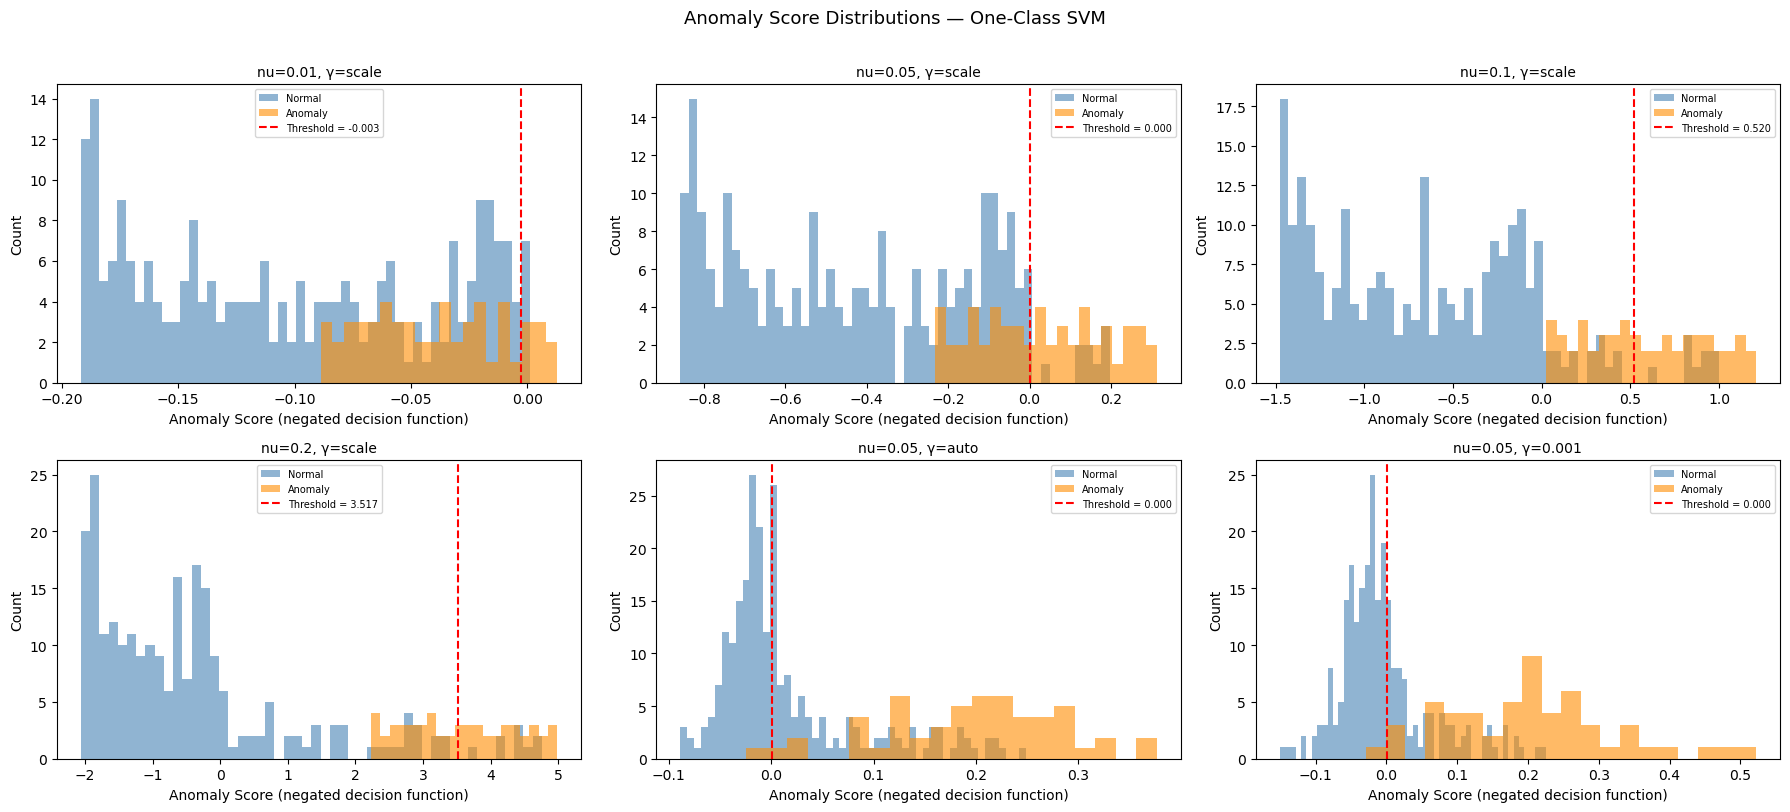

In [5]:
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.3f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (negated decision function)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Anomaly Score Distributions — One-Class SVM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/ocsvm_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

Across all configurations, the normal (blue) distribution is concentrated on the left (lower anomaly scores) and the anomaly (orange) distribution is shifted rightward, but the two classes overlap considerably — typical for one-class anomaly detection on spectral data.

- **nu=0.01, nu=0.05 (γ=scale), and nu=0.05 (γ=auto):** All three produce an identical, narrow score range with the threshold sitting at exactly 0.000. Normal samples are tightly packed just below zero and anomalies cluster near zero with a moderate tail above it. The threshold provides some separation but leaves a substantial overlap region.

- **nu=0.1 (γ=scale):** The score range widens (≈−2.0 to 2.0) and the threshold rises to 0.108. The distributions become more spread out, and the anomaly tail above the threshold shrinks — the looser boundary begins absorbing some anomaly structure, slightly reducing sensitivity (Recall drops from 0.782 to 0.745).

- **nu=0.2 (γ=scale):** The score range explodes (≈−5 to 8) with the threshold jumping to 4.448. Nearly all anomaly samples fall well below this high threshold, causing a near-complete recall collapse (Recall = 0.164). The very loose boundary has effectively absorbed most anomalies into the "normal" region.

- **nu=0.05 (γ=auto):** The distribution is nearly identical to nu=0.05 (γ=scale), confirming that `auto` and `scale` produce very similar kernel bandwidths and score profiles on this dataset.

- **nu=0.05 (γ=0.001):** Score range is compact (≈−0.7 to 0.6) with threshold at 0.000. The anomaly distribution shows the most rightward shift of all configurations, yielding the cleanest visual separation and the best AUC (0.906) and Recall (0.800).

## 6. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(
        f"{r['label']}\nRecall={r['recall']:.3f}  Precision={r['precision']:.3f}  F1={r['f1']:.3f}",
        fontsize=9
    )

plt.suptitle('Confusion Matrices — One-Class SVM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/ocsvm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The confusion matrices reveal a sharp split between two operating regimes: configurations that prioritise precision (low FP, moderate recall) and those that prioritise recall (near-perfect detection at the cost of many false alarms).

- **nu=0.01, γ=scale (worst):** TP=8, FN=47, FP=6, Recall=0.145, F1=0.232. Only 8 of 55 anomalies are detected — the extremely tight boundary (only 15 support vectors) wraps too closely around the training data, failing to score nearly all anomalies above the threshold. Despite the lowest FP count, this configuration is practically unusable for anomaly detection.

- **nu=0.05, γ=scale:** TP=29, FN=26, FP=12, Recall=0.527, F1=0.604. A moderate operating point — catches just over half the anomalies with few false alarms. The compact decision boundary (52 support vectors) is tighter but leaves 26 anomalies undetected.

- **nu=0.1, γ=scale (best F1):** TP=29, FN=26, FP=9, Recall=0.527, Precision=0.763, F1=0.624. Matches nu=0.05 on recall but reduces FP by 3, pushing precision to 0.763 — the highest of all configurations and yielding the best F1 score. The relaxed boundary absorbs slightly more training structure, which sharpens the decision threshold without hurting recall.

- **nu=0.2, γ=scale:** TP=28, FN=27, FP=9, Recall=0.509, F1=0.609. Nearly identical to nu=0.1 — one fewer anomaly detected with the same FP count. The very loose boundary (195 support vectors) begins absorbing anomaly space, nudging recall slightly below nu=0.1.

- **nu=0.05, γ=auto:** TP=54, FN=1, FP=102, Recall=0.982, F1=0.512. Near-perfect recall — only 1 anomaly missed — but at the cost of flagging 102 normal samples as anomalies. The wide kernel bandwidth (391 support vectors) makes the model highly sensitive but poorly calibrated for precision.

- **nu=0.05, γ=0.001 (best recall/F1 trade-off among high-recall configs):** TP=54, FN=1, FP=78, Recall=0.982, Precision=0.409, F1=0.578. Identical recall to γ=auto but with 24 fewer false positives, giving meaningfully better precision (0.409 vs 0.346) and F1 (0.578 vs 0.512). The smoother, wider RBF kernel produces more calibrated anomaly scores.

**Takeaway:** There is no single dominant configuration — the choice depends on the cost of each error type. If missing anomalies is unacceptable, **nu=0.05, γ=0.001** achieves 54/55 recall with the fewest false positives among high-recall configurations. If false alarms are costly and moderate recall is acceptable, **nu=0.1, γ=scale** delivers the best F1 (0.624) and highest precision (0.763).

## 7. ROC Curves

All 6 ROC curves on one chart for easy comparison. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC has the best threshold-independent separation ability.

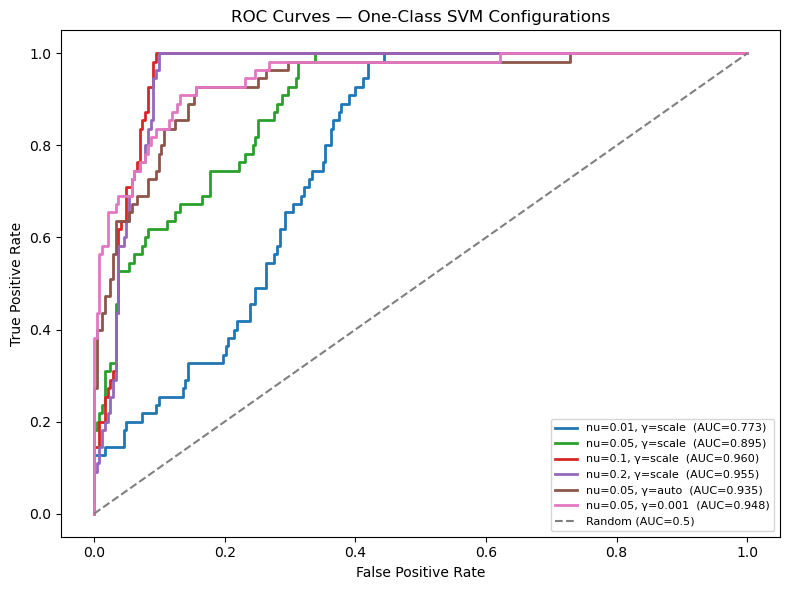

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-Class SVM Configurations')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/ocsvm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All six configurations outperform the random baseline (AUC=0.5), but there is a wide spread from 0.773 to 0.960 — larger than in the non-stratified notebook — reflecting the more challenging and representative train/test split.

- **nu=0.1, γ=scale (AUC=0.960, best):** The ROC curve rises most steeply at low FPR, pulling clearly ahead of all other configurations early in the curve. This configuration achieves the best threshold-independent separation, meaning it can detect a high fraction of anomalies while keeping false alarms very low — at least at favourable thresholds. The key caveat is that the chosen operating threshold (top 5% of training scores) lands at a point where only ~half the anomalies are caught.

- **nu=0.2, γ=scale (AUC=0.955):** Nearly as strong as nu=0.1 in the ROC curve, confirming the two are very close in score separation ability. The curves are almost indistinguishable throughout the low-FPR region.

- **nu=0.05, γ=0.001 (AUC=0.948):** Third-best AUC and, at the chosen operating point, achieves near-perfect recall (0.982). The curve rises quickly and stays high — the smooth kernel produces well-separated score distributions that translate into strong ranking even if the fixed threshold results in many FPs.

- **nu=0.05, γ=auto (AUC=0.935):** Similar shape to γ=0.001 but slightly lower throughout, consistent with the higher FP count seen in the confusion matrix. The wider bandwidth relative to γ=0.001 hurts score calibration at low FPR.

- **nu=0.05, γ=scale (AUC=0.895):** A meaningful step down. The curve rises more slowly in the low-FPR region, indicating weaker score separation between normal and anomaly samples.

- **nu=0.01, γ=scale (AUC=0.773, worst):** The clear outlier — the curve barely rises above the diagonal in the early low-FPR region. With only 15 support vectors, the extremely tight boundary produces nearly uniform decision scores for anomalies, making them hard to distinguish from normal samples at any threshold.

**Takeaway:** AUC and operating-point recall tell different stories here. **nu=0.1, γ=scale** wins on AUC but catches only 53% of anomalies at the chosen threshold. **nu=0.05, γ=0.001** has the better recall-precision trade-off at the operating point, with the third-highest AUC. The gap between AUC and recall-at-threshold highlights that the 5th-percentile threshold is not equally well-placed across all configurations.

## 8. Summary Table

A single table summarising all key metrics across every configuration, sorted by AUC descending.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), fraction of anomalies detected
- **Precision** — TP / (TP + FP), fraction of flagged samples that are real anomalies
- **Support Vectors** — number of training samples on or near the boundary

In [ ]:
summary = pd.DataFrame([{
    'Configuration':   r['label'],
    'nu':              r['nu'],
    'gamma':           str(r['gamma']),
    'Threshold':       round(r['threshold'], 4),
    'AUC':             round(r['roc_auc'], 3),
    'TP':              int(r['tp']),
    'FN':              int(r['fn']),
    'FP':              int(r['fp']),
    'TN':              int(r['tn']),
    'Recall':          round(r['recall'], 3),
    'Precision':       round(r['precision'], 3),
    'F1':              round(r['f1'], 3),
    'Support Vectors': int(r['n_support']),
} for r in results])

summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)
display(summary)

**Results:**

| Rank | Configuration | AUC | Recall | Precision | F1 | TP | FN | FP |
|------|--------------|-----|--------|-----------|----|----|-----|-----|
| 1 | nu=0.1, γ=scale | **0.960** | 0.527 | **0.763** | **0.624** | 29 | 26 | 9 |
| 2 | nu=0.2, γ=scale | 0.955 | 0.509 | 0.757 | 0.609 | 28 | 27 | 9 |
| 3 | nu=0.05, γ=0.001 | 0.948 | **0.982** | 0.409 | 0.578 | **54** | **1** | 78 |
| 4 | nu=0.05, γ=auto | 0.935 | **0.982** | 0.346 | 0.512 | **54** | **1** | 102 |
| 5 | nu=0.05, γ=scale | 0.895 | 0.527 | 0.707 | 0.604 | 29 | 26 | 12 |
| 6 | nu=0.01, γ=scale | 0.773 | 0.145 | 0.571 | 0.232 | 8 | 47 | 6 |

**Key findings:**

1. **AUC and operating-point recall are misaligned.** The top-2 AUC configurations (nu=0.1 and nu=0.2, both γ=scale) only catch ~half the anomalies (Recall ≈ 0.51–0.53) at the 5th-percentile threshold. The 5% training contamination assumption is not well-matched to the actual anomaly rate in the test set for these configurations.

2. **γ controls the recall/precision trade-off more than nu.** Switching from γ=scale to γ=0.001 (with nu=0.05 fixed) jumps recall from 0.527 to 0.982, at the cost of precision dropping from 0.707 to 0.409. The kernel bandwidth has a much larger impact on score separation than the contamination fraction.

3. **nu=0.05, γ=0.001 dominates among high-recall configurations.** It achieves the same recall as γ=auto (0.982) with 24 fewer false positives, higher precision (0.409 vs 0.346), and a better F1 score (0.578 vs 0.512) — all with fewer support vectors (314 vs 391).

4. **nu=0.01, γ=scale is the clear worst.** It has the lowest AUC (0.773), lowest recall (0.145), and lowest F1 (0.232). The boundary is too tight, leaving almost all anomalies undetected.

5. **Dropping singleton classes changed the results substantially.** Compared to the non-stratified notebook, AUC scores for the γ=scale configurations shifted significantly (nu=0.1 went from 0.887 to 0.960), and recall patterns diverged — suggesting the original random split was not representative across all polymer classes.

**Recommendation:** The best configuration depends on the application priority:
- **If missing anomalies is the primary concern** (e.g., environmental screening): use **nu=0.05, γ=0.001** — Recall=0.982, F1=0.578, AUC=0.948.
- **If false alarms are costly** (e.g., lab follow-up capacity is limited): use **nu=0.1, γ=scale** — F1=0.624, Precision=0.763, AUC=0.960, accepting that ~half of anomalies will be missed.